In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import json
import os

plt.style.use("../../plotStyle.mplstyle")

In [2]:
import sys
from copy import deepcopy
sys.path.append("../../models")

import pyGameWorld as pgw
from pyGameWorld import viewer

pygame 2.5.2 (SDL 2.28.3, Python 3.8.19)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
predictions = pd.read_csv("predictions.csv")
print(predictions.shape)
predictions["worldtype"] = predictions.worldtype.map(lambda x: "filler" if pd.isna(x) else x)
memory = pd.read_csv("memory.csv")
memory["correct"] = memory.correct_conf.map(lambda x: 1.0 if x > 50 else 0.0)

(2475, 16)


In [4]:
pids = predictions.query("world == 'catch' & correct == 1")["pid"].unique()
print(predictions.pid.nunique() - pids.shape[0])
predictions = predictions.query("pid in @pids")
memory = memory.query("pid in @pids")
print(predictions.shape)

7
(2300, 16)


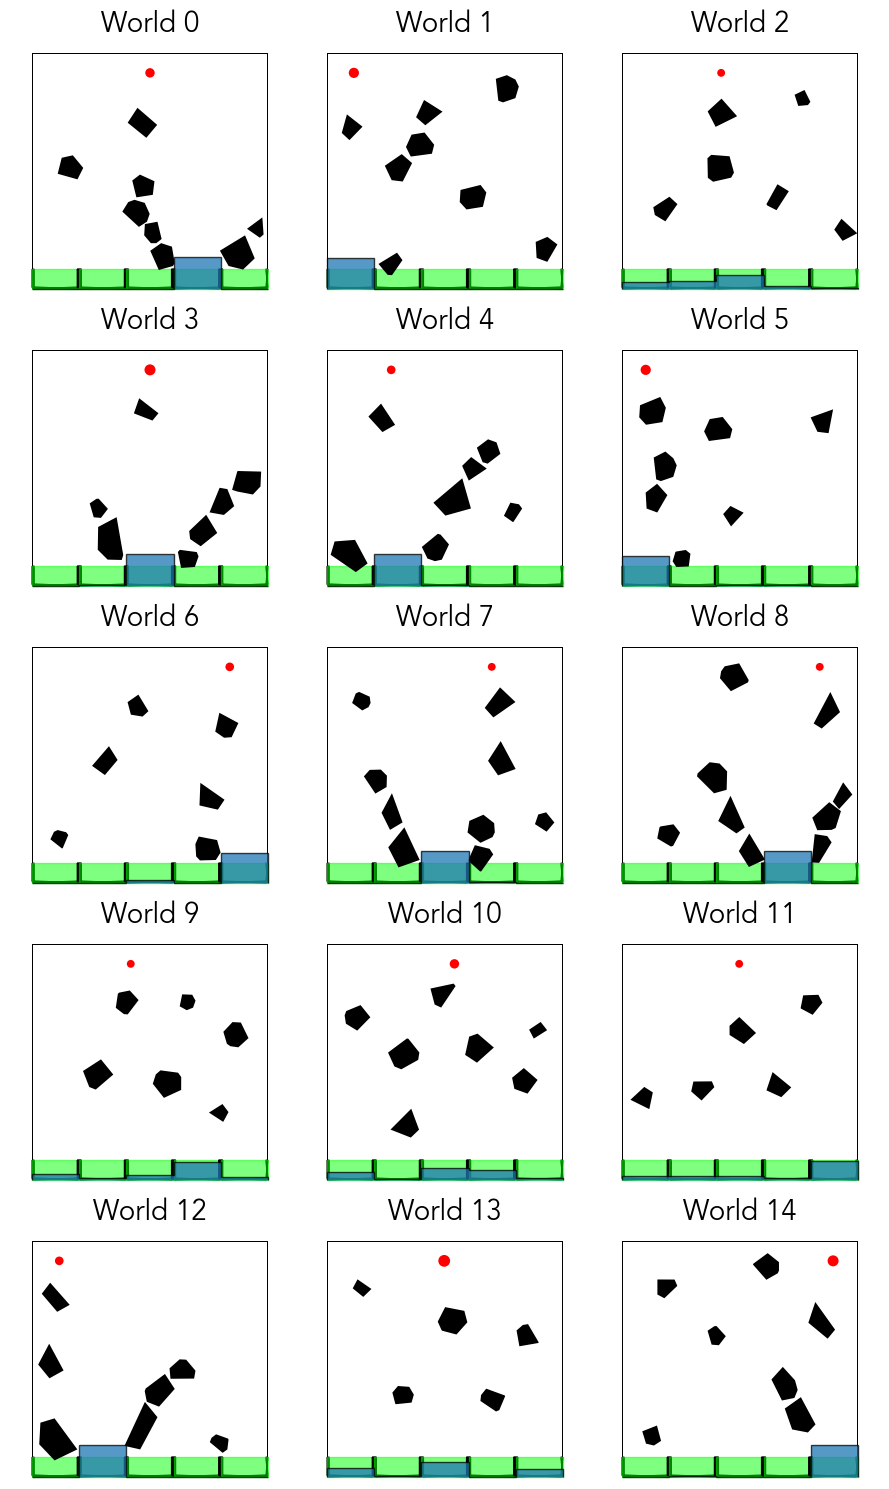

In [5]:
definite_worlds = predictions.query("filler == False").world.unique()
plt.figure(figsize=(9, 15))
for i, w in enumerate(definite_worlds):
    with open(f"../../experiments/assets/exp_vgc2/targets/{w}/world.json") as f:
        jdict = json.load(f)

    plt.subplot(5, 3, i+1)
    world = pgw.loadFromDict(jdict["world"])
    viewer._draw_world_mpl(world)
    counts, bins = np.histogram(predictions.query(f"world == '{w}' & delete == False & filler == False").response * 120, bins=[0, 120, 240, 360, 480, 600], density=True)
    plt.stairs(counts * 10000, bins, fill=True, facecolor="tab:blue", ec="k", lw=1, alpha=0.75)
    plt.title(f"World {i}", fontdict={"fontsize": 20})
    plt.gca().autoscale_view()
    plt.axis("off")
    plt.axis("equal")

plt.tight_layout()
plt.savefig("../../figures/exp_vgc_stimuli.pdf")

(-30.0, 630.0, -30.0, 630.0)

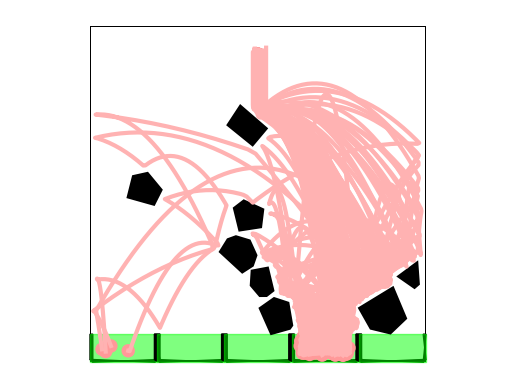

In [6]:
w = definite_worlds[0]

with open(f"../../experiments/assets/exp_vgc2/targets/{w}/world.json") as f:
    jdict = json.load(f)

world = pgw.loadFromDict(jdict["world"])
viewer._draw_world_mpl(world)
viewer._draw_paths_mpl(world, [p["path"] for p in jdict["outcome"]["noisePaths"]])
plt.axis("equal")
plt.axis("off")

In [7]:
worlds = {wname: json.load(open(f"../../experiments/assets/exp_vgc2/targets/{wname}/world.json")) for wname in predictions.query("filler == False").world.unique()}

In [8]:
from importlib import reload
reload(pgw.viewer)

<module 'pyGameWorld.viewer' from '/Users/tony/repos/plinko-repro/data/exp_vgc2/../../models/pyGameWorld/viewer/__init__.py'>

In [9]:
pd.read_csv("../../models/output/exp1/noisysim_pars_search.csv").sort_values("rmse").head()

,Unnamed: 0,noise_position_moving,noise_collision_direction,noise_collision_elasticity,epsilon,rmse,r
917,917,5.0,0.8,0.6,0.10,0.064560,0.985642
907,907,4.0,0.7,0.6,0.10,0.066411,0.984828
747,747,3.0,0.0,0.5,0.15,0.067488,0.984605
755,755,3.0,0.8,0.5,0.15,0.067589,0.984690
881,881,1.0,0.8,0.6,0.10,0.068263,0.983735


In [10]:
import process_model

with open("../../stimuli/default_sim_noise.json") as f:
    sim_noise = json.load(f)

# best fitting noise parameters from exp1
sim_noise = {
    **sim_noise,
    **{
        "noise_position_moving": 5.0,
        "noise_collision_direction": 0.8,
        "noise_collision_elasticity": 0.6,
    },
}
sim_noise

{'noise_position_static': 0,
 'noise_position_moving': 5.0,
 'noise_collision_direction': 0.8,
 'noise_collision_elasticity': 0.6,
 'noise_gravity': 0,
 'noise_object_friction': 0,
 'noise_object_density': 0,
 'noise_object_elasticity': 0}

In [11]:
rerun = False
if rerun:
    jit_pred_df = []
    jit_pred = {}
    for wname, world in worlds.items():
        print(wname)

        out = process_model.process_model(pgw.loadFromDict(world["world"]), 25, 1000, sim_noise, decay=0.0)
        jit_pred[wname] = out[0]
        jit_pred_df.append(pd.Series(out[0]).reset_index().rename(columns={"index": "object", 0: "prob"}).assign(world=wname, worldtype=world["worldType"]))

    jit_pred_df = pd.concat(jit_pred_df, ignore_index=True)
    jit_pred_df.to_csv("jit_predictions.csv", index=False)
else:
    jit_pred_df = pd.read_csv("jit_predictions.csv")

In [12]:
import baseline_models as baseline
reload(baseline)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



<module 'baseline_models' from '/Users/tony/repos/plinko-repro/data/exp_vgc2/../../models/baseline_models.py'>

RMSE: 0.106


<Figure size 300x300 with 0 Axes>

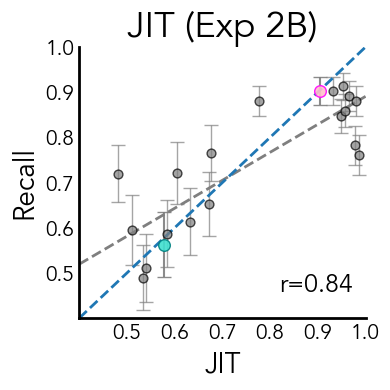

In [13]:
plt.figure(figsize=(3, 3))
joint_predictions = pd.merge(
    memory.groupby(["world", "object"]).correct.agg(["mean", lambda x: x.sem()]).reset_index().rename(columns={"mean": "correct", "<lambda_0>": "correct_ci"}),
    jit_pred_df,
    on=["world", "object"]
)
chance = 0.333
joint_predictions["prob"] = joint_predictions.prob * (1 - chance) + chance
joint_predictions["special"] = "no"
joint_predictions.loc[joint_predictions.world == "lh_ll_unlink_plinko_0001", "special"] = "irrelevant"
joint_predictions.loc[(joint_predictions.world ==  "hh_hl_unlink_plinko_0202") & (joint_predictions.object == "bottombump_0"), "special"] = "relevant"
plt.figure(figsize=(4, 4))
# plt.scatter(joint_predictions.prob, joint_predictions.correct, s=40, alpha=0.7, color="tab:gray", lw=1, ec="k")
# p = sns.relplot(
#     x="prob", y="correct", data=joint_predictions, kind="scatter",
#     s=40, alpha=0.7, hue="worldtype", lw=1, edgecolor="k"
# )
# p.legend.set_visible(False)
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(40), alpha=0.7, capsize=5, color="tab:gray", lw=1, markeredgecolor="k", data=joint_predictions.loc[joint_predictions.special == "no"]
)
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(70), alpha=0.9, capsize=5, color="pink", ecolor="tab:gray", lw=1.5, markeredgecolor="magenta", data=joint_predictions.loc[joint_predictions.special == "irrelevant"]
)
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(70), alpha=0.9, capsize=5, color="turquoise", ecolor="tab:gray", lw=1.5, markeredgecolor="teal", data=joint_predictions.loc[joint_predictions.special == "relevant"]
)

lims = (0.40, 1.0)
plt.xlim(lims)
plt.ylim(lims)
a, b = np.polyfit(joint_predictions.prob, joint_predictions.correct, 1)
plt.plot([lims[0], 1], [a * lims[0] + b, a + b], color="tab:gray", lw=2, ls="--")
plt.plot([lims[0], 1], [lims[0], 1], color="tab:blue", lw=2, ls="--")

plt.xticks(np.arange(0.5, 1.05, 0.1))
plt.yticks(np.arange(0.5, 1.05, 0.1))

plt.xlabel("JIT")
plt.ylabel("Recall")
plt.title("JIT (Exp 2B)")
# plt.text(0.8, 0.4, f"r = {joint_predictions.prob.corr(joint_predictions.correct):.2f}", fontdict={"size": 18, "weight": "bold"})
plt.legend([], [], title=f"r={joint_predictions.prob.corr(joint_predictions.correct):.2f}", loc="lower right", frameon=False, title_fontproperties={"size": 18, "weight": "bold"})
print(f"RMSE: {np.sqrt(((joint_predictions.correct - joint_predictions.prob) ** 2).mean()):.3f}")
plt.tight_layout()
plt.savefig("../../figures/exp_vgc_jit.pdf")

In [14]:
joint_predictions.groupby("world").apply(lambda x: (x.prob - x.correct).abs().min()).sort_values()

world
lh_ll_unlink_plinko_0001    0.002516
hh_hl_unlink_plinko_0246    0.003737
hh_hl_unlink_plinko_0202    0.016080
lh_ll_unlink_plinko_0000    0.028617
hh_hl_unlink_plinko_0269    0.029735
lh_hh_trNM_plinko_0001      0.039423
hh_hl_unlink_plinko_0393    0.043790
lh_hh_plinko_0002           0.073739
hh_hl_unlink_plinko_0240    0.084147
lh_hh_trNM_plinko_0000      0.097928
lh_hh_plinko_0003           0.099973
lh_hh_plinko_0001           0.101045
lh_hh_trNM_plinko_0002      0.104702
lh_ll_unlink_plinko_0002    0.194478
lh_hh_plinko_0000           0.224876
dtype: float64

exp 2A -99.11855165274373 61.482807839703796
exp 2B -0.352942605013373 0.2760881096647829
scaling factor 280.83475966010997


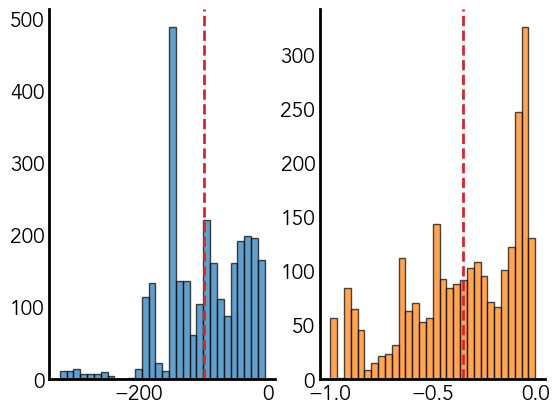

In [15]:
exp2a_utilities = []
for filename in os.listdir("../../models/output/exp1/cache/"):
    if filename.endswith(".json"):
        with open(os.path.join("../../models/output/exp1/cache/", filename)) as f:
            construal = json.load(f)
        utilities = [c["utility"] for c in construal]
        exp2a_utilities.extend(utilities)

exp2b_utilities = []
for filename in os.listdir("../../models/output/exp_vgc2/cache/"):
    if filename.endswith(".json"):
        with open(os.path.join("../../models/output/exp_vgc2/cache/", filename)) as f:
            construal = json.load(f)
        utilities = [c["utility"] for c in construal]
        exp2b_utilities.extend(utilities)

plt.subplot(1, 2, 1)
print("exp 2A", np.mean(exp2a_utilities), np.std(exp2a_utilities))
plt.hist(exp2a_utilities, bins=30, color="tab:blue", edgecolor="k", alpha=0.7)
plt.axvline(np.mean(exp2a_utilities), color="tab:red", lw=2, ls="--")

plt.subplot(1, 2, 2)
print("exp 2B", np.mean(exp2b_utilities), np.std(exp2b_utilities))
plt.hist(exp2b_utilities, bins=30, color="tab:orange", edgecolor="k", alpha=0.7)
plt.axvline(np.mean(exp2b_utilities), color="tab:red", lw=2, ls="--")

utility_scaling = np.mean(exp2a_utilities) / np.mean(exp2b_utilities)
print("scaling factor", utility_scaling)

In [17]:
utility_scaling = 280.83
# best fitting alpha from exp1
alpha = 20.096

_vgc_pred_df = []
for w, wdict in worlds.items():
    print(w)
    with open(f"../../models/output/exp_vgc2/cache/{w}_construals.json") as f:
        construal = json.load(f)

    for c in construal:
        c["utility"] *= utility_scaling
        c["score"] = c["utility"] - len(c["construal"])

    preds = baseline.vgc_object_preds(construal, temperature=alpha)
    _vgc_pred_df.append(pd.Series(preds).reset_index().rename(columns={"index": "object", 0: "prob"}).assign(world=w, worldtype=wdict["worldType"]))

vgc_pred_df = pd.concat(_vgc_pred_df, ignore_index=True)
vgc_pred_df

lh_ll_unlink_plinko_0000
lh_hh_plinko_0000
hh_hl_unlink_plinko_0202
lh_hh_plinko_0002
lh_ll_unlink_plinko_0001
lh_hh_trNM_plinko_0000
lh_hh_plinko_0003
lh_hh_trNM_plinko_0001
lh_hh_plinko_0001
hh_hl_unlink_plinko_0269
hh_hl_unlink_plinko_0246
hh_hl_unlink_plinko_0240
lh_ll_unlink_plinko_0002
hh_hl_unlink_plinko_0393
lh_hh_trNM_plinko_0002


,object,prob,world,worldtype
0,topbump_0,0.387571,lh_ll_unlink_plinko_0000,maybe
1,topbump_1,0.799423,lh_ll_unlink_plinko_0000,maybe
2,bottombump_0,0.577764,lh_ll_unlink_plinko_0000,maybe
3,bottombump_1,0.991172,lh_ll_unlink_plinko_0000,maybe
4,bottombump_2,0.806129,lh_ll_unlink_plinko_0000,maybe
...,...,...,...,...
99,bottombump_1,0.487641,lh_hh_trNM_plinko_0002,definite
100,bottombump_2,0.483481,lh_hh_trNM_plinko_0002,definite
101,bump_5,0.483056,lh_hh_trNM_plinko_0002,definite
102,bump_6,0.493502,lh_hh_trNM_plinko_0002,definite


RMSE: 0.306


<Figure size 300x300 with 0 Axes>

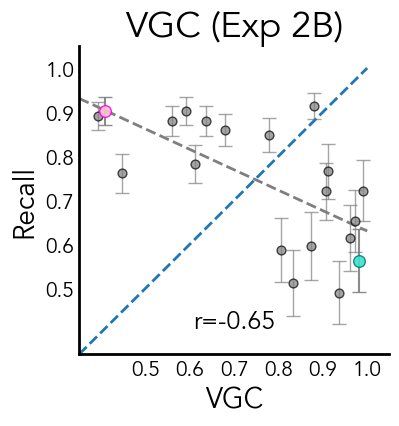

In [18]:
plt.figure(figsize=(3, 3))
joint_predictions = pd.merge(
    memory.groupby(["world", "object"]).correct.agg(["mean", lambda x: x.sem()]).reset_index().rename(columns={"mean": "correct", "<lambda_0>": "correct_ci"}),
    vgc_pred_df,
    on=["world", "object"]
)
joint_predictions["correct"]
chance = 0.333
joint_predictions["prob"] = joint_predictions.prob * (1 - chance) + chance
joint_predictions["special"] = "no"
joint_predictions.loc[joint_predictions.world == "lh_ll_unlink_plinko_0001", "special"] = "irrelevant"
# joint_predictions.loc[joint_predictions.world ==  "hh_hl_unlink_plinko_0202", "special"] = "relevant"
joint_predictions.loc[(joint_predictions.world ==  "hh_hl_unlink_plinko_0202") & (joint_predictions.object == "bottombump_0"), "special"] = "relevant"
plt.figure(figsize=(4, 4))
# plt.scatter(joint_predictions.prob, joint_predictions.correct, s=40, alpha=0.7, color="tab:gray", lw=1, ec="k")
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(40), alpha=0.7, capsize=5, color="tab:gray", lw=1, markeredgecolor="k", data=joint_predictions.loc[joint_predictions.special == "no"]
)
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(70), alpha=0.9, capsize=5, color="pink", ecolor="tab:gray", lw=1.5, markeredgecolor="magenta", data=joint_predictions.loc[joint_predictions.special == "irrelevant"]
)
plt.errorbar(
    "prob", "correct", yerr="correct_ci", fmt="o", ms=np.sqrt(70), alpha=0.9, capsize=5, color="turquoise", ecolor="tab:gray", lw=1.5, markeredgecolor="teal", data=joint_predictions.loc[joint_predictions.special == "relevant"]
)
lims = (0.35, 1.05)
plt.xlim(lims)
plt.ylim(lims)

plt.xticks(np.arange(0.5, 1.05, 0.1))
plt.yticks(np.arange(0.5, 1.05, 0.1))

a, b = np.polyfit(joint_predictions.prob, joint_predictions.correct, 1)
plt.plot([lims[0], 1], [a * lims[0] + b, a + b], color="tab:gray", lw=2, ls="--")
plt.plot([lims[0], 1], [lims[0], 1], color="tab:blue", lw=2, ls="--")

plt.xlabel("VGC")
plt.ylabel("Recall")
plt.title("VGC (Exp 2B)")
# plt.text(0.5, 0.4, f"r = {joint_predictions.prob.corr(joint_predictions.correct):.2f}", fontdict={"size": 18, "weight": "bold"})
plt.legend([], [], title=f"r={joint_predictions.prob.corr(joint_predictions.correct):.2f}", loc="lower center", frameon=False, title_fontproperties={"size": 18, "weight": "bold"})
print(f"RMSE: {np.sqrt(((joint_predictions.correct - joint_predictions.prob) ** 2).mean()):.3f}")
# plt.savefig("../../figures/exp_vgc_vgc.pdf", bbox_inches="tight")

In [19]:
joint_predictions.groupby("world").apply(lambda x: (x.prob - x.correct).abs().max()).sort_values(ascending=False)

world
lh_hh_plinko_0002           0.499579
lh_ll_unlink_plinko_0001    0.494540
hh_hl_unlink_plinko_0393    0.446041
hh_hl_unlink_plinko_0202    0.417973
hh_hl_unlink_plinko_0269    0.321042
lh_hh_trNM_plinko_0002      0.320508
hh_hl_unlink_plinko_0246    0.319790
lh_hh_plinko_0000           0.313449
lh_ll_unlink_plinko_0000    0.310664
hh_hl_unlink_plinko_0240    0.278367
lh_hh_plinko_0003           0.243333
lh_hh_trNM_plinko_0000      0.179499
lh_ll_unlink_plinko_0002    0.170423
lh_hh_plinko_0001           0.070018
lh_hh_trNM_plinko_0001      0.032282
dtype: float64

In [20]:
from pyGameWorld.simulate import simulate_noisypaths

[('Human', 0.9021739130434783), ('JIT', 0.9046904058031064), ('VGC', 0.4076337459786793)]


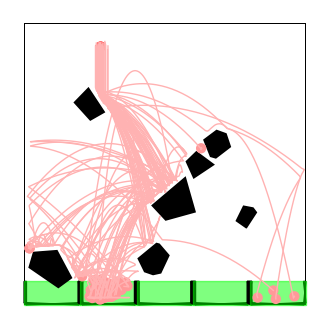

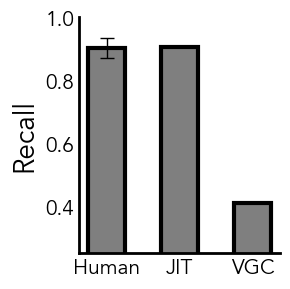

In [21]:
wname = "lh_ll_unlink_plinko_0001"
# draw_prediction(worlds[wname], jit_pred[wname], None, default_color=(175, 175, 175, 255))


# plt.subplot(1, 2, 1)
plt.figure(figsize=(4, 4))
viewer._draw_world_mpl(
    pgw.loadFromDict(worlds[wname]["world"]),
)
paths = simulate_noisypaths(pgw.loadFromDict(worlds[wname]["world"]), 1/60, N=50, **sim_noise)
viewer._draw_paths_mpl(
    pgw.loadFromDict(worlds[wname]["world"]),
    [p["path"] for p in paths],
    pathSize=1,
    # path_kwargs={"color": "purple", "alpha": 0.5, "lw": 1},
)
plt.axis("off")
plt.axis("equal")
plt.gca().autoscale_view()
plt.savefig("../../figures/exp_vgc_example_world1.pdf", bbox_inches="tight", dpi=300)

# plt.subplot(1, 2, 2)
plt.figure(figsize=(3, 3))
probed_objects = memory.query(f"world == '{wname}'").object.unique()
probed_predictions = []
for obj in probed_objects:
    # probed_predictions.append(("Human", memory.query(f"world == '{wname}' & object == '{obj}'").correct.mean() * 0.5 + 0.5))
    # probed_predictions.append(("JIT", jit_pred_df.loc[(jit_pred_df.world == wname) & (jit_pred_df.object == obj), "prob"].item() * 0.5 + 0.5))
    # probed_predictions.append(("VGC", vgc_pred_df.loc[(vgc_pred_df.world == wname) & (vgc_pred_df.object == obj), "prob"].clip(0.05, 1).item() * 0.5 + 0.5))
    probed_predictions.append(("Human", memory.query(f"world == '{wname}' & object == '{obj}'").correct.mean()))
    probed_predictions.append(("JIT", jit_pred_df.loc[(jit_pred_df.world == wname) & (jit_pred_df.object == obj), "prob"].item() * .667 + 0.333))
    probed_predictions.append(("VGC", vgc_pred_df.loc[(vgc_pred_df.world == wname) & (vgc_pred_df.object == obj), "prob"].clip(0.001, 1).item() * .667 + 0.333))
print(probed_predictions)
sns.barplot(data=pd.DataFrame(probed_predictions, columns=["model", "pred"]), x="model", y="pred", width=0.5, color="tab:gray", lw=3, ec="k")
plt.errorbar(x=["Human"], y=[memory.query(f"world == '{wname}'").correct.mean()], yerr=[memory.query(f"world == '{wname}'").correct.sem()], fmt="none", capsize=5, color="k", lw=1)
plt.ylim(0.5-0.25, 1.0)
plt.ylabel("Recall")
plt.xlabel("")
# plt.yticks([], [])
plt.tight_layout()
plt.savefig("../../figures/exp_vgc_jit_vgc_examplepred1.pdf", bbox_inches="tight", dpi=300)

[('Human', 0.6136363636363636), ('JIT', 0.6328445360203179), ('VGC', 0.9618485947669975)]


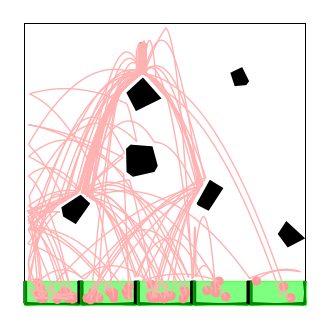

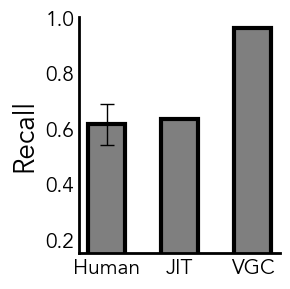

In [22]:
wname = "hh_hl_unlink_plinko_0202"
# wname = list(worlds.keys())[3]

plt.figure(figsize=(4, 4))
viewer._draw_world_mpl(
    pgw.loadFromDict(worlds[wname]["world"]),
)
paths = simulate_noisypaths(pgw.loadFromDict(worlds[wname]["world"]), 1/60, N=50, **sim_noise)
viewer._draw_paths_mpl(
    pgw.loadFromDict(worlds[wname]["world"]),
    [p["path"] for p in paths],
    pathSize=1,
    # path_kwargs={"color": "purple", "alpha": 0.1, "lw": 0.1},
)
plt.axis("off")
plt.axis("equal")
plt.gca().autoscale_view()
plt.savefig("../../figures/exp_vgc_example_world2.pdf", bbox_inches="tight", dpi=300)

# plt.subplot(1, 2, 2)
plt.figure(figsize=(3, 3))
probed_objects = memory.query(f"world == '{wname}'").object.unique()
probed_predictions = []
for obj in probed_objects[:1]:
    probed_predictions.append(("Human", memory.query(f"world == '{wname}' & object == '{obj}'").correct.mean()))#  * 0.5 + 0.5))
    probed_predictions.append(("JIT", jit_pred_df.loc[(jit_pred_df.world == wname) & (jit_pred_df.object == obj), "prob"].item() * .667 + 0.333))
    probed_predictions.append(("VGC", vgc_pred_df.loc[(vgc_pred_df.world == wname) & (vgc_pred_df.object == obj), "prob"].clip(0.001, 1).item() * .667 + 0.333))
print(probed_predictions)
sns.barplot(data=pd.DataFrame(probed_predictions, columns=["model", "pred"]), x="model", y="pred", width=0.5, color="tab:gray", lw=3, ec="k", errorbar=None)
plt.errorbar(x=["Human"], y=[memory.query(f"world == '{wname}' & object == '{obj}'").correct.mean()], yerr=[memory.query(f"world == '{wname}' & object == '{obj}'").correct.sem()], fmt="none", capsize=5, color="k", lw=1)
plt.ylim(0.5-0.35, 1.0)
plt.ylabel("Recall")
plt.xlabel("")
# plt.yticks([], [])
plt.tight_layout()
plt.savefig("../../figures/exp_vgc_jit_vgc_examplepred2.pdf", bbox_inches="tight", dpi=300)

In [23]:
import cmocean

def draw_prediction(jdict, pred, cmap, norm, default_color=(240, 240, 240), **kw):
    if not cmap:
        # cmap = mpl.colormaps["Blues"]
        cmap = cmocean.cm.algae
    jdict = deepcopy(jdict)
    colors = {}
    world = pgw.loadFromDict(jdict["world"])
    for oname in world.objects:
        if "bump" in oname:
            if oname in pred:
                colors[oname] = [255 * x for x in cmap(norm(pred[oname]))]
            else:
                colors[oname] = default_color

    viewer._draw_world_mpl(pgw.loadFromDict(jdict["world"]), obj_colors=colors, **kw)

In [24]:
# plt.figure(figsize=(9, 30))
def heatmap(vgc_pred_df, jit_pred_df, memory, wname, jdict, norm, axes=None):
    vgc_colors = vgc_pred_df.loc[vgc_pred_df.world == wname].set_index("object").prob.to_dict()
    jit_colors = jit_pred_df.loc[jit_pred_df.world == wname].set_index("object").prob.to_dict()

    probed_objects = memory.query(f"world == '{wname}'").object.unique()
    vgc_colors = {k: 0.667 * v + 0.333 for k, v in vgc_colors.items() if k in probed_objects}
    jit_colors = {k: 0.667 * v + 0.333 for k, v in jit_colors.items() if k in probed_objects}
    print(probed_objects)

    hatches = {}
    widths = {}

    for oname in jdict["world"]["objects"]:
        if "bump" not in oname:
            continue
        if oname in probed_objects:
            widths[oname] = 1.0
            hatches[oname] = {"hatch": "", "edgecolor": "k", "ls": "-"}
        else:
            widths[oname] = 1.0
            hatches[oname] = {"hatch": "////", "edgecolor": "gray", "ls": "-"}

    # plt.subplot(1, 3, i)
    plt.sca(axes[0])
    pred = memory.query(f"world == '{wname}'")
    # human = ((pred.groupby("object").correct_conf.mean() / 100 - 0.5) * 2).to_dict()
    human = ((pred.groupby("object").correct.mean() - 0.5) * 2).to_dict()
    draw_prediction(jdict, human, None, norm, obj_widths=widths, other_object_props=hatches)

    plt.gca().autoscale_view()
    plt.axis("equal")
    plt.title("Human", fontsize=15)

    # plt.subplot(1, 3, i+1)
    plt.sca(axes[1])
    draw_prediction(jdict, jit_colors, None, norm, obj_widths=widths, other_object_props=hatches)
    plt.axis("equal")
    plt.gca().autoscale_view()
    plt.title("JIT", fontsize=15)

    # plt.subplot(1, 3, i+2)
    plt.sca(axes[2])
    draw_prediction(jdict, vgc_colors, None, norm, obj_widths=widths, other_object_props=hatches)
    plt.axis("equal")
    plt.gca().autoscale_view()
    plt.title("VGC", fontsize=15)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        ax.spines[:].set_visible(False)

In [25]:
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib

norm = matplotlib.colors.Normalize(vmin=memory.groupby("object").correct.mean().min(), vmax=1)
print(memory.groupby("object").correct.mean().min())

0.4897959183673469


['topbump_0']
['topbump_3']
['bump_4' 'bottombump_0']
['bottombump_0']
['bump_5']
['bottombump_0']
['topbump_1']
['topbump_0']


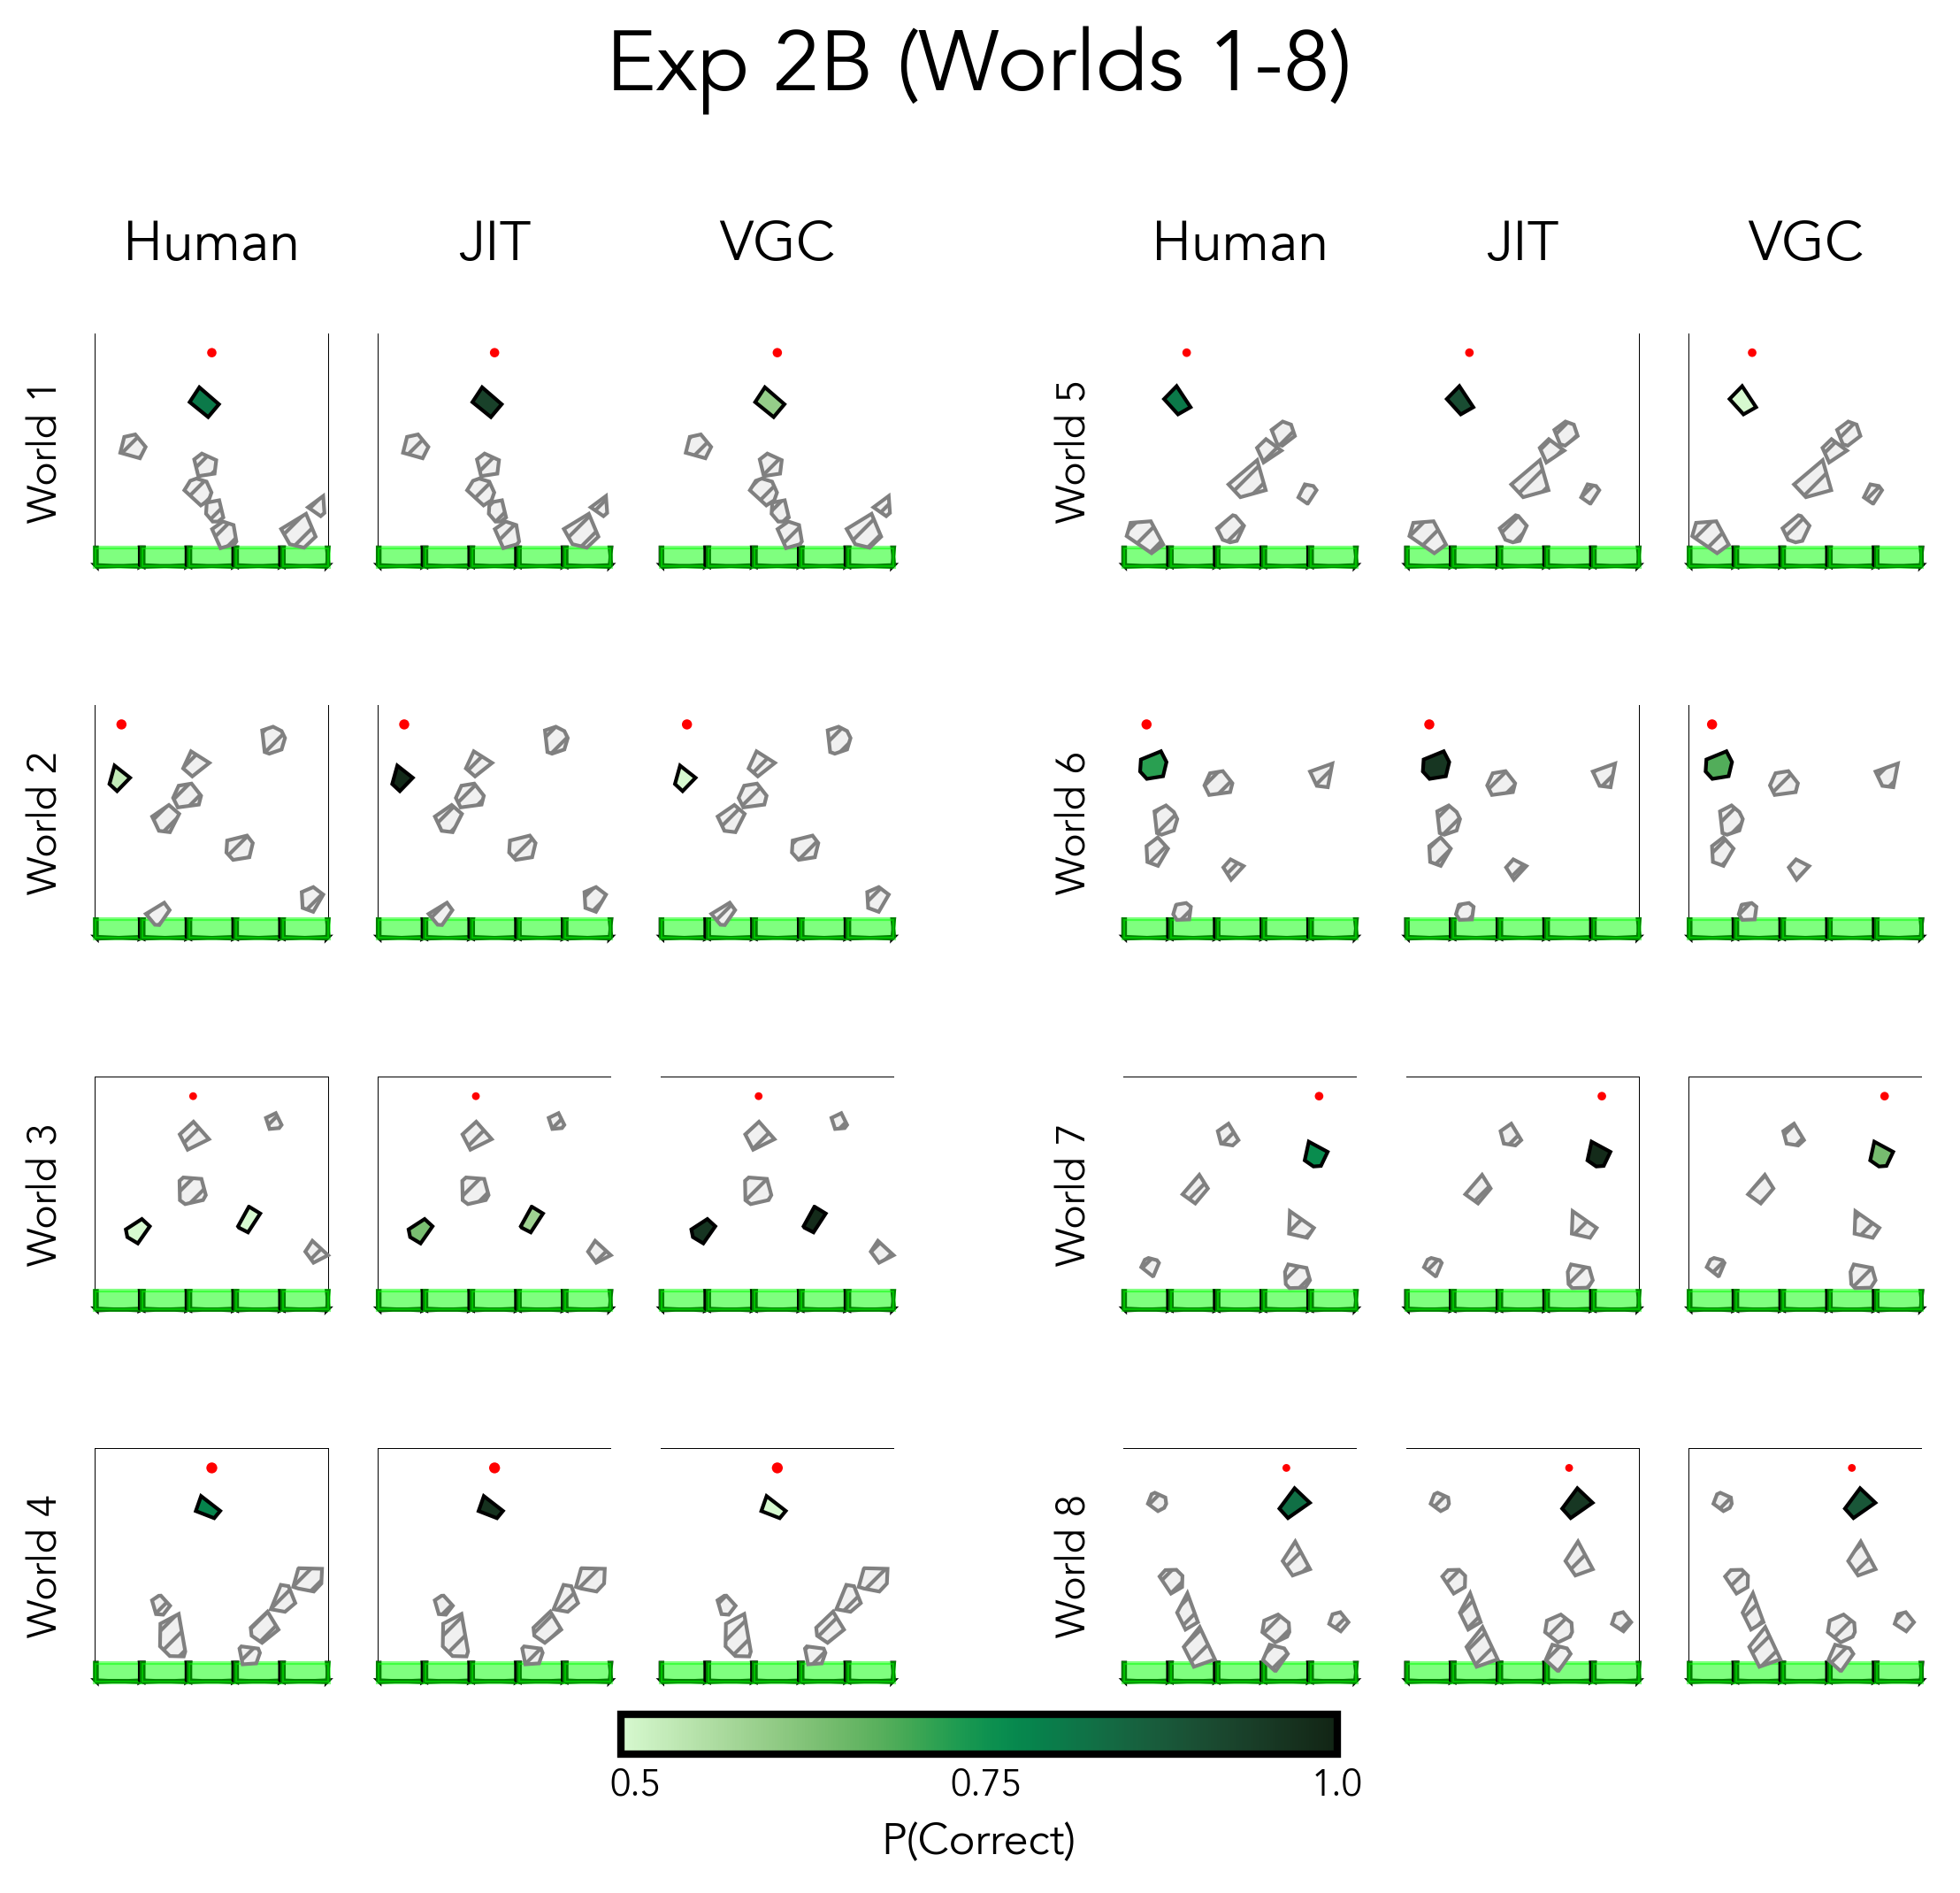

In [26]:
fig = plt.figure(figsize=(1.5 * 6, 2.1 * 4 - 1), dpi=300)
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
left = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[0], wspace=0.1, hspace=0.1)
right = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[1], wspace=0.1, hspace=0.1)
for j, gs in enumerate([left, right]):
    for i, (wname, world) in enumerate(list(worlds.items())[j*4:(j+1)*4]):
        axes = []
        for k in range(3):
            axes.append(fig.add_subplot(gs[i, k]))
        heatmap(vgc_pred_df, jit_pred_df, memory, wname, world, norm, axes=axes)
        axes[0].set_ylabel(f"World {j*4 + i+1}", fontsize=11)
        if i % 4 != 0:
            for ax in axes:
                ax.set_title("")
fig.suptitle("Exp 2B (Worlds 1-8)")
fig.subplots_adjust(top=0.85)
colorbar_ax = fig.add_axes([0.35, 0.1, 0.3, 0.02])
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('P(Correct)', fontsize=12)
cbar.ax.set_xticks([0.5, 0.75, 1.0], ['0.5', '0.75', '1.0'], fontsize=10)
fig.savefig("../../figures/exp_vgc_heatmaps1.pdf", bbox_inches="tight")

['topbump_0']
['topbump_3' 'topbump_1']
['bump_4' 'bump_6']
['topbump_0' 'bottombump_1']
['topbump_2']
['bottombump_3' 'bottombump_2']
['bottombump_0']


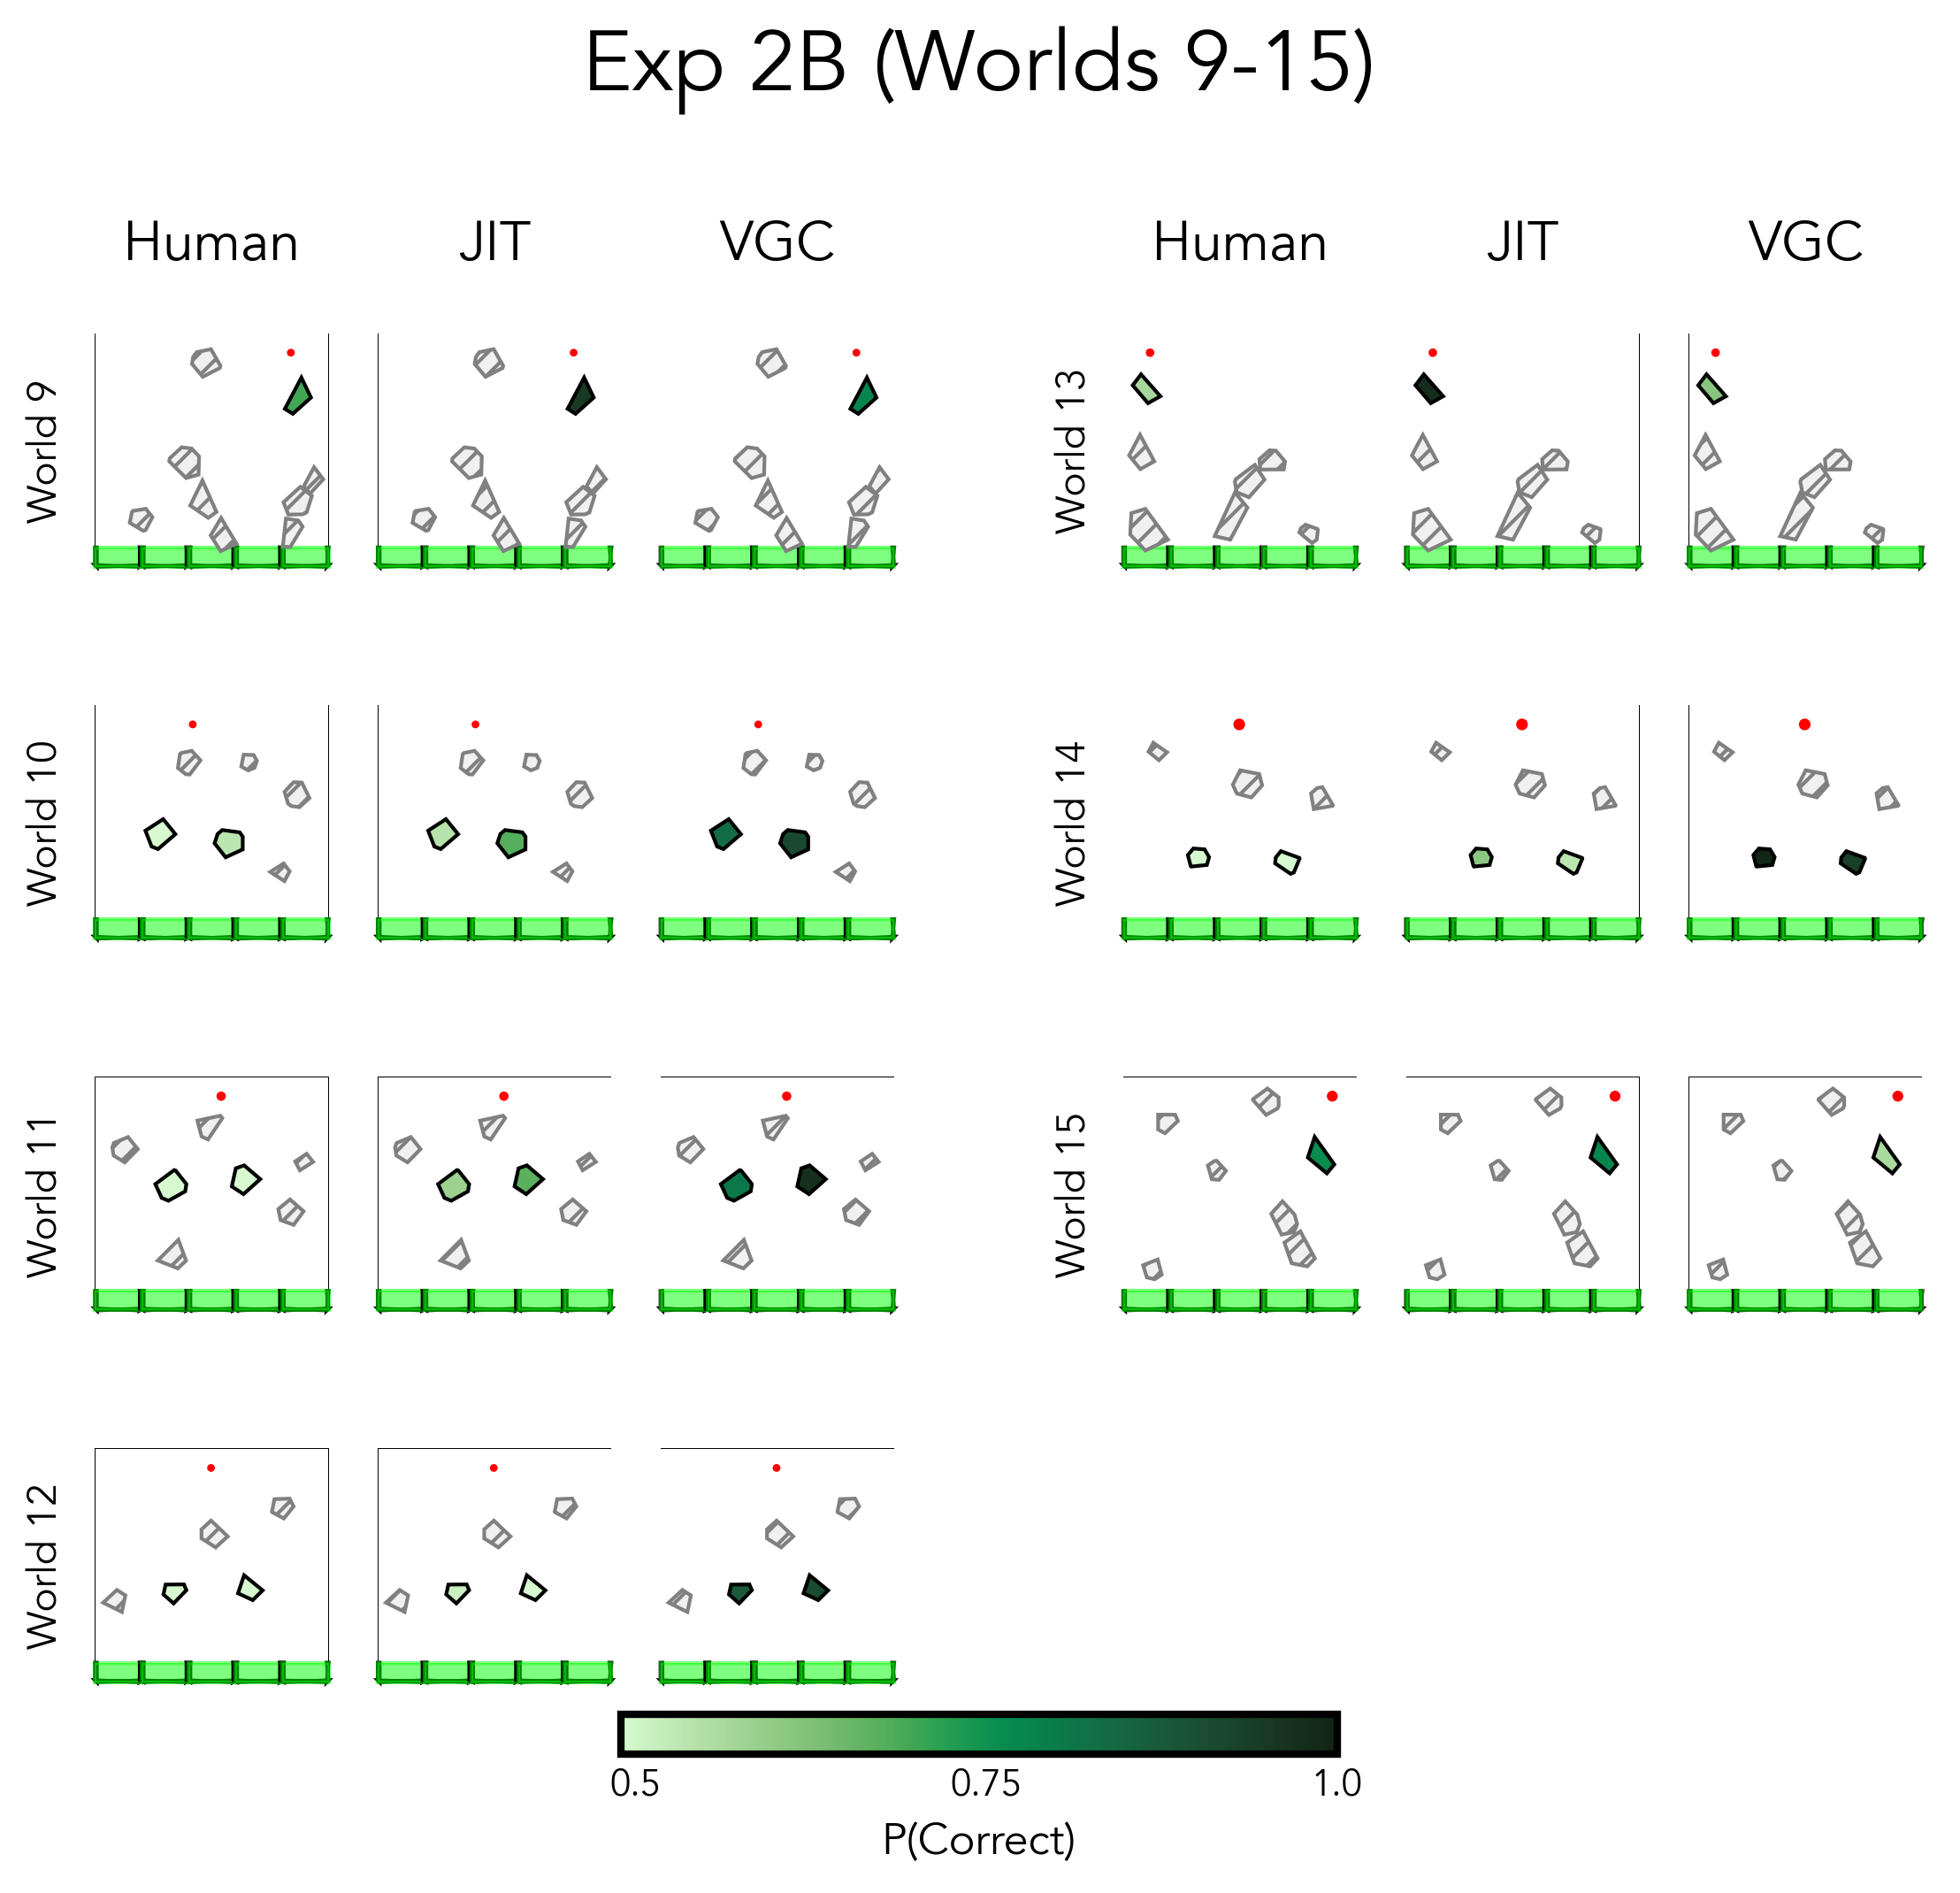

In [27]:
fig = plt.figure(figsize=(1.5 * 6, 2.1 * 4 - 1), dpi=300)
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
left = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[0], wspace=0.1, hspace=0.1)
right = gridspec.GridSpecFromSubplotSpec(4, 3, subplot_spec=outer[1], wspace=0.1, hspace=0.1)
for j, gs in enumerate([left, right]):
    for i, (wname, world) in enumerate(list(worlds.items())[(8+j*4):(8+(j+1)*4)]):
        axes = []
        for k in range(3):
            axes.append(fig.add_subplot(gs[i, k]))
        heatmap(vgc_pred_df, jit_pred_df, memory, wname, world, norm, axes=axes)
        axes[0].set_ylabel(f"World {8+j*4 + i+1}", fontsize=11)
        if i % 4 != 0:
            for ax in axes:
                ax.set_title("")
fig.suptitle("Exp 2B (Worlds 9-15)")
fig.subplots_adjust(top=0.85)
colorbar_ax = fig.add_axes([0.35, 0.1, 0.3, 0.02])
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmocean.cm.algae), cax=colorbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('P(Correct)', fontsize=12)
cbar.ax.set_xticks([0.5, 0.75, 1.0], ['0.5', '0.75', '1.0'], fontsize=10)
fig.savefig("../../figures/exp_vgc_heatmaps2.pdf", bbox_inches="tight")

['topbump_3' 'topbump_1']
['topbump_0' 'bottombump_1']


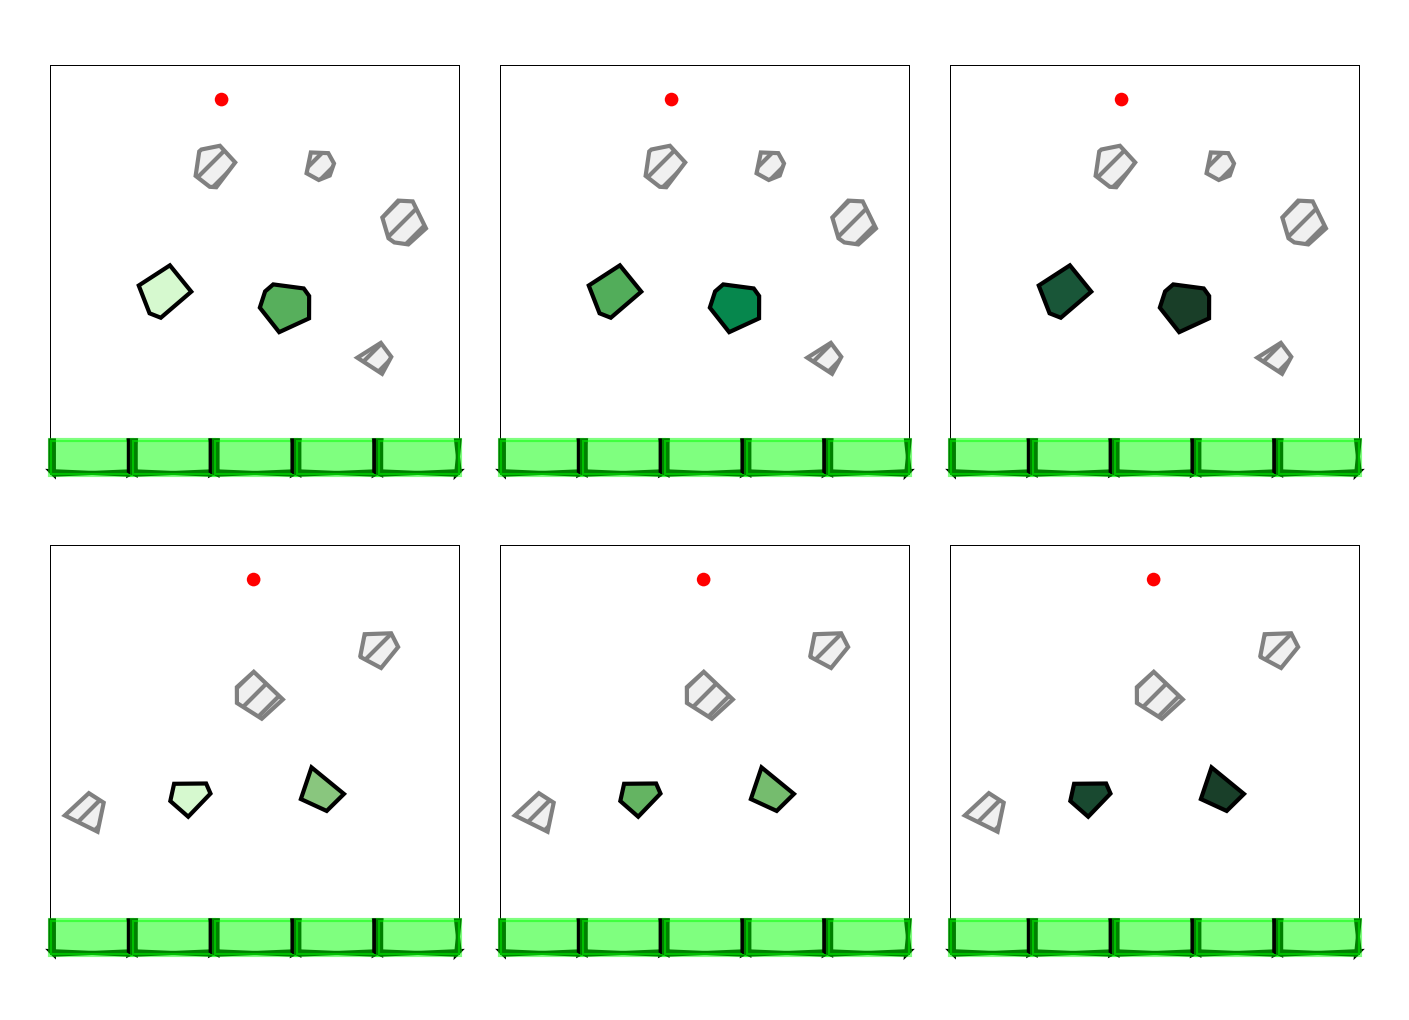

In [28]:
display_worlds = [9, 11]# , 10, 13]
norm = matplotlib.colors.Normalize(vmin=0.268, vmax=1)

rows = len(display_worlds)
fig = plt.figure(figsize=(1.5 * 3, 2.1 * rows - 1), dpi=300)
for j, i in enumerate(display_worlds):
    wname, world = list(worlds.items())[i]
    axes = []
    for k in range(3):
        axes.append(plt.subplot(len(display_worlds), 3, j * 3 + k + 1))
    heatmap(vgc_pred_df, jit_pred_df, memory, wname, world, norm, axes=axes)
    for ax in axes:
        ax.set_title("")
# plt.suptitle("Exp 2B (Worlds 1-15)")
fig.subplots_adjust(hspace=0.01, wspace=1.5)
plt.tight_layout(pad=0.0)
plt.savefig("../../figures/exp_vgc_heatmaps.pdf", bbox_inches="tight", dpi=300)